STUDENTS EXAMINATION PERFORMANCE PREDICTION ANALYSIS.

This is a machine learning predictive analysis report to show how habits and locality can influence student performance.

IMPORTING THE PACKAGES 

Importing pandas for data processing.

Numpy for linear algebra.

Matplotlib.pyplot for data visualization.

Seaborn for statistical data visualization.

Sklearn for predictive Machine Learning analysis.



In [115]:

import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 
sns.set (style='darkgrid',  font_scale=1.2)     
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)




IMPORTING THE DATASET 


 importing the students data csv file and finding out basic statistical insights about the given data.


In [95]:
data= pd.read_csv('/home/georgyyy/Documents/python/dataset practice/student_exam_performance.csv') 
print("Shape of the dataset:", data.shape)




Shape of the dataset: (100000, 44)


Exploratory Data Analysis (EDA)

Quick check on the data types, null entries, duplicates and  basic statistics.

We would check the null entries and fill them out depending on the data types, mode for categorical and median for numerical.

In [105]:
data.head(5)

,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,attendance_percentage,assignment_completion_rate,class_participation,study_hours_per_day,self_study_hours,private_tuition,online_learning_hours,study_consistency,study_environment,study_method,revision_frequency,practice_tests_completed,notes_quality,sleep_hours,sleep_quality,daily_screen_time,physical_activity_hours,break_frequency,stress_level,motivation_level,internet_access,device_availability,educational_app_usage,online_course_hours,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score,performance_grade,pass_status,performance_level
0,STU_000001,20,Female,High School,Public,Middle,NaN,Rural,78.36,2.95,81.49,65.18,Medium,4.94,2.63,0,1.75,Medium,Moderate,Flashcards,Rarely,8,Average,6.31,Excellent,3.80,0.93,Frequently,10,High,1,Shared,Low,2.15,Medium,27,95,86,NaN,9.39,90.40,A,Pass,High
1,STU_000002,17,Male,High School,Public,Middle,NaN,Suburban,73.40,2.89,NaN,76.53,Low,3.42,2.64,0,1.97,Medium,Moderate,Flashcards,Daily,10,Average,6.81,Excellent,4.04,0.21,Frequently,8,High,1,Shared,Moderate,4.37,Easy,4,100,86,87.17,6.31,86.21,A,Pass,High
2,STU_000003,18,Other,Undergraduate,Public,Middle,Master,Urban,82.76,3.35,100.00,70.39,Medium,1.06,0.83,0,3.40,Low,Moderate,Summarizing,Weekly,5,Excellent,6.53,Poor,3.19,2.56,Rarely,9,Medium,1,Dedicated,Low,1.43,Easy,28,96,74,63.77,9.87,76.11,B,Pass,Medium
3,STU_000004,20,Male,High School,Public,Middle,High School,Suburban,60.61,2.57,84.91,75.06,Low,7.89,5.51,0,1.94,Medium,Quiet,Summarizing,Weekly,8,Excellent,6.60,Fair,5.12,2.30,Rarely,10,High,1,Dedicated,Low,3.69,Medium,16,97,77,59.51,9.68,79.74,B,Pass,Medium
4,STU_000005,16,Female,High School,Private,High,Bachelor,Suburban,74.79,2.84,88.21,61.54,Medium,2.63,2.29,0,0.58,Medium,Noisy,Self-Reading,Rarely,1,Poor,7.83,Excellent,4.82,0.49,Frequently,10,High,1,Dedicated,Moderate,1.97,Medium,28,98,52,84.64,10.00,50.66,D,Pass,Low


In [103]:
data.tail(5)

,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,attendance_percentage,assignment_completion_rate,class_participation,study_hours_per_day,self_study_hours,private_tuition,online_learning_hours,study_consistency,study_environment,study_method,revision_frequency,practice_tests_completed,notes_quality,sleep_hours,sleep_quality,daily_screen_time,physical_activity_hours,break_frequency,stress_level,motivation_level,internet_access,device_availability,educational_app_usage,online_course_hours,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score,performance_grade,pass_status,performance_level
99995,STU_099996,17,Male,Undergraduate,Public,Upper-Middle,NaN,Suburban,78.73,NaN,89.67,60.97,High,1.16,0.68,0,1.56,Medium,Moderate,Flashcards,Weekly,7,Average,7.00,Fair,7.69,4.29,Occasionally,8,Medium,1,Shared,High,6.43,Medium,5,95,62,76.13,8.36,66.46,C,Pass,Medium
99996,STU_099997,14,Female,High School,Public,Upper-Middle,Bachelor,Suburban,75.70,2.98,83.87,94.38,Medium,8.59,6.63,0,0.49,Medium,Noisy,Group Study,Weekly,12,NaN,6.73,Excellent,2.57,3.60,Frequently,10,Low,1,Dedicated,Low,4.34,Easy,24,94,91,84.29,8.68,96.54,A,Pass,High
99997,STU_099998,16,Female,High School,Public,Upper-Middle,High School,Suburban,84.69,3.27,89.57,71.28,Medium,2.45,2.20,0,4.33,High,Moderate,Summarizing,Rarely,5,Average,7.20,Fair,4.80,1.62,Occasionally,9,Medium,1,Dedicated,Moderate,11.91,Medium,24,85,65,62.32,9.97,74.66,C,Pass,Medium
99998,STU_099999,15,Female,High School,Private,High,Master,Rural,74.70,3.06,92.61,69.26,Medium,4.77,3.92,1,0.41,Medium,Quiet,Summarizing,Weekly,7,Average,8.37,Poor,4.40,2.21,Rarely,10,Medium,1,Shared,Moderate,0.55,Medium,28,93,81,100.00,10.00,85.85,A,Pass,High
99999,STU_100000,18,Female,Undergraduate,Charter,Lower-Middle,NaN,Urban,76.73,2.97,90.32,81.80,Medium,4.11,3.69,1,0.67,Medium,Moderate,Practice Tests,Weekly,5,Average,6.89,Good,6.71,0.92,Rarely,10,Low,1,Dedicated,Low,9.80,Medium,1,92,52,NaN,10.00,54.40,D,Pass,Low


In [17]:
data.describe()


,age,previous_exam_score,previous_gpa,attendance_percentage,assignment_completion_rate,study_hours_per_day,self_study_hours,private_tuition,online_learning_hours,practice_tests_completed,sleep_hours,daily_screen_time,physical_activity_hours,stress_level,internet_access,online_course_hours,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score
count,100000.000000,100000.000000,92207.000000,90137.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,90387.000000,100000.000000,100000.000000
mean,17.005740,69.531033,2.780892,84.616882,69.724405,2.995725,2.094970,0.299800,2.004763,5.509170,6.995102,5.000495,2.487579,9.375640,0.918760,2.999453,15.501440,92.492150,57.298240,78.398551,8.927373,61.950072
std,1.999562,11.379108,0.478218,7.922485,12.127179,1.719466,1.266066,0.458173,2.005719,2.501131,1.200874,1.775716,2.413386,1.081613,0.273205,2.983732,8.644356,4.609376,15.028787,14.105155,1.354875,15.863644
min,14.000000,30.000000,1.000000,46.340000,20.000000,0.500000,0.250000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,5.000000,0.000000,0.000000,1.000000,85.000000,0.000000,17.030000,1.000000,0.000000
25%,15.000000,61.820000,2.460000,79.210000,61.480000,1.720000,1.170000,0.000000,0.580000,4.000000,6.180000,3.770000,0.720000,9.000000,1.000000,0.860000,8.000000,88.000000,47.000000,68.790000,8.220000,51.240000
50%,17.000000,69.530000,2.780000,84.750000,69.570000,2.670000,1.840000,0.000000,1.380000,5.000000,7.000000,4.990000,1.730000,10.000000,1.000000,2.080000,16.000000,92.000000,57.000000,79.000000,9.490000,61.960000
75%,19.000000,77.232500,3.110000,90.170000,77.920000,3.910000,2.730000,1.000000,2.770000,7.000000,7.810000,6.210000,3.480000,10.000000,1.000000,4.150000,23.000000,96.000000,67.000000,89.210000,10.000000,72.730000
max,20.000000,100.000000,4.000000,100.000000,100.000000,12.000000,10.000000,1.000000,15.000000,20.000000,11.000000,12.080000,12.000000,10.000000,1.000000,20.000000,30.000000,100.000000,100.000000,100.000000,10.000000,100.000000


In [98]:

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 44 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   student_id                  100000 non-null  str    
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  str    
 3   education_level             100000 non-null  str    
 4   school_type                 100000 non-null  str    
 5   family_income               100000 non-null  str    
 6   parent_education            93474 non-null   str    
 7   urban_rural                 100000 non-null  str    
 8   previous_exam_score         100000 non-null  float64
 9   previous_gpa                92207 non-null   float64
 10  attendance_percentage       90137 non-null   float64
 11  assignment_completion_rate  100000 non-null  float64
 12  class_participation         100000 non-null  str    
 13  study_hours_per_day       

In [99]:
null_entries = data.isnull().sum()
null_entries =null_entries[null_entries > 0].sort_values(ascending=False)
print("Columns with null entries:\n", null_entries)

Columns with null entries:
 attendance_percentage    9863
time_management_score    9613
notes_quality            8407
previous_gpa             7793
sleep_quality            6994
parent_education         6526
device_availability      2965
dtype: int64


CHECKING FOR DUPLICATES.

In [102]:
duplicate_entries = data['student_id'].duplicated().sum()
print("Number of duplicate entries:", duplicate_entries)


Number of duplicate entries: 0


Notes from  the analysis
 1) There are 100000 rows and 44 Columns 
 2) There are huge numbers of null entries and thus removing them may result in an inaccuracy.

FINDING THE FINAL EXAM PASS MARK


In [78]:
data.groupby('pass_status')['exam_score'].agg(['min', 'max'])

,min,max
pass_status,,
Fail,0.0,49.99
Pass,50.0,100.00


VISUALISATION OF THE BASIC STATISTICS FROM THE EXPLORATORY ANALYSIS PROCESS>

Pass Status Distribution:
 pass_status
Pass    77389
Fail    22611
Name: count, dtype: int64


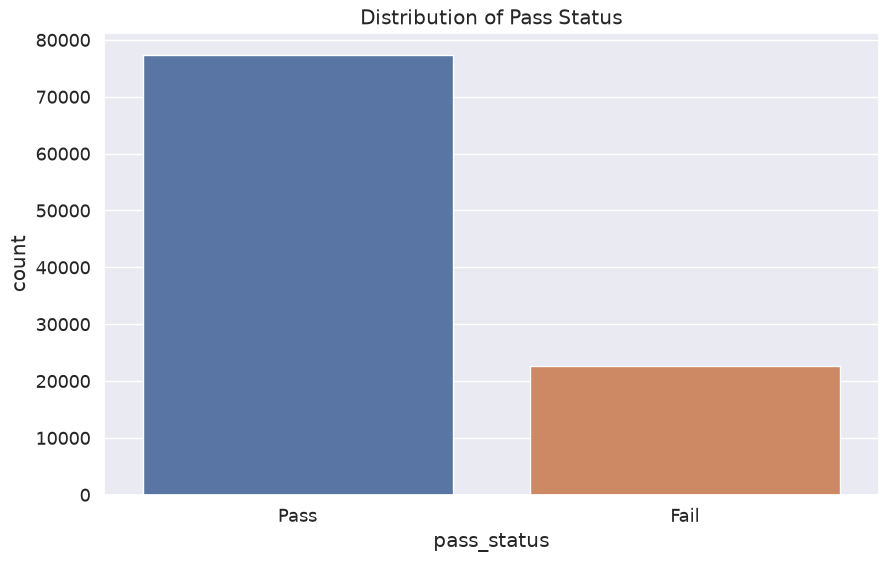

In [82]:
sns.countplot(data=data, x='pass_status', hue='pass_status')
plt.title('Distribution of Pass Status')
print("Pass Status Distribution:\n", data['pass_status'].value_counts())

PERFORMANCE IN RELATION TO STUDY HABITS.

Plots to show how the habits such as study  hours etc affect the students performance.

We first start off by looking at the distribution of the target prediction; exam scores

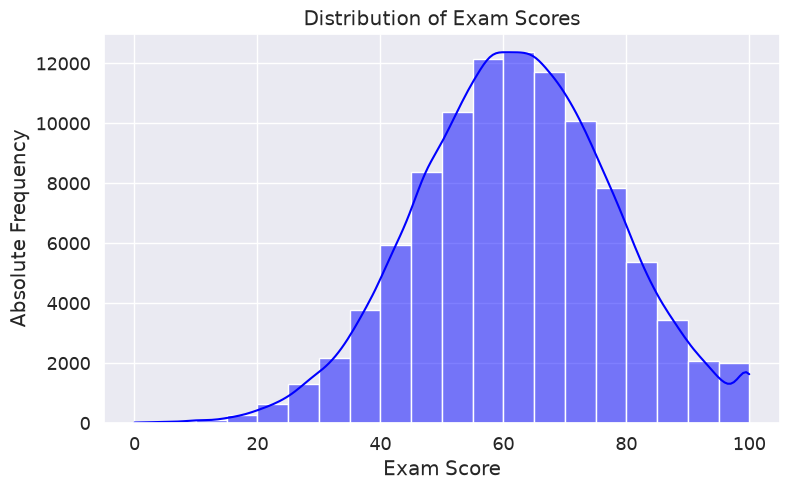

In [90]:
if 'exam_score' in data.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data['exam_score'], kde=True, color='blue', bins=20)
    plt.title('Distribution of Exam Scores')
    plt.xlabel('Exam Score')
    plt.ylabel('Absolute Frequency')
    plt.tight_layout()
    plt.show()

1. Study Hour Allocation

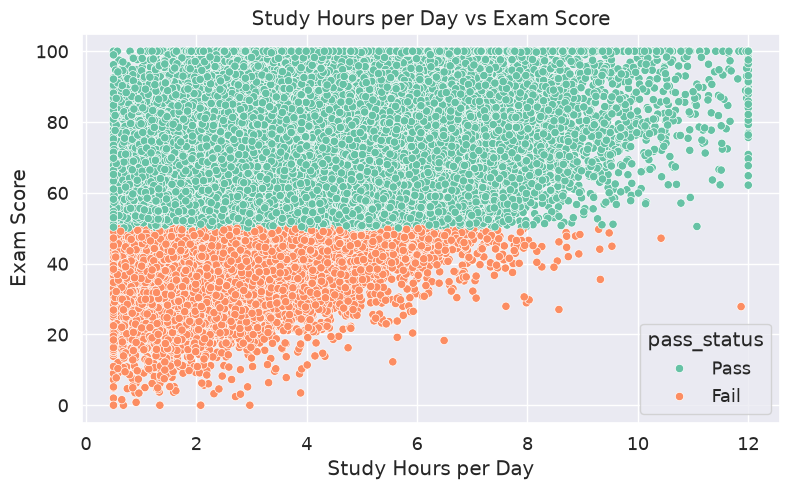

In [110]:


if 'study_hours_per_day' in data.columns and 'exam_score' in data.columns:
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=data, x='study_hours_per_day', y='exam_score', hue='pass_status' if 'pass_status' in data.columns else None, palette='Set2')
    plt.title('Study Hours per Day vs Exam Score')
    plt.xlabel('Study Hours per Day')
    plt.ylabel('Exam Score')
    plt.tight_layout()
    plt.show()





    

Conclusion is that the students who allocate more self study hours pass examinations than the ones who allocate less.

2) Class Attendance

This concludes that students who had a higher class attendance percentage than others passed his/her final examinations.

3) Previous GPA

Average Previous GPA by Pass Status:
 pass_status
Fail    2.480577
Pass    2.868783
Name: previous_gpa, dtype: float64


Text(0, 0.5, 'Average Previous GPA')

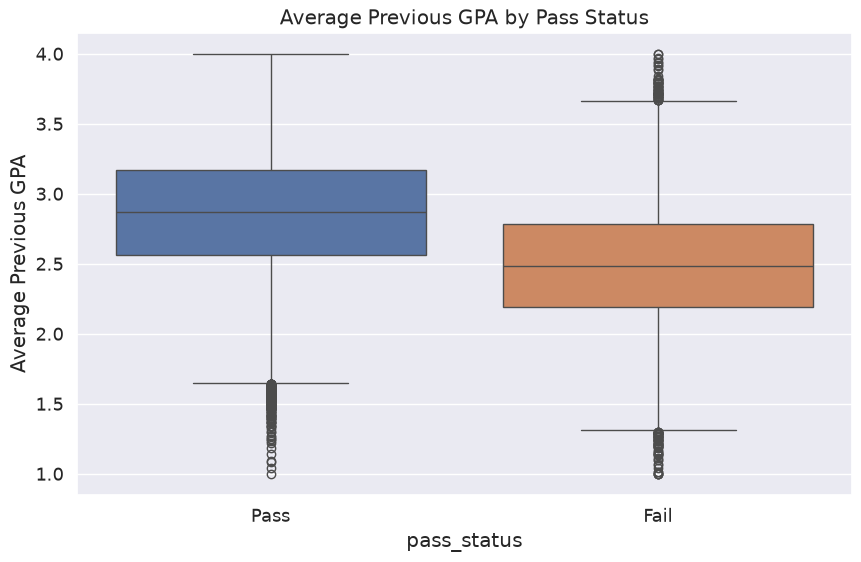

In [84]:
sns.boxplot(data=data, x='pass_status', y='previous_gpa', hue='pass_status')
print("Average Previous GPA by Pass Status:\n", data.groupby('pass_status')['previous_gpa'].mean())
plt.title('Average Previous GPA by Pass Status')
plt.ylabel('Average Previous GPA')

4. Stress level 

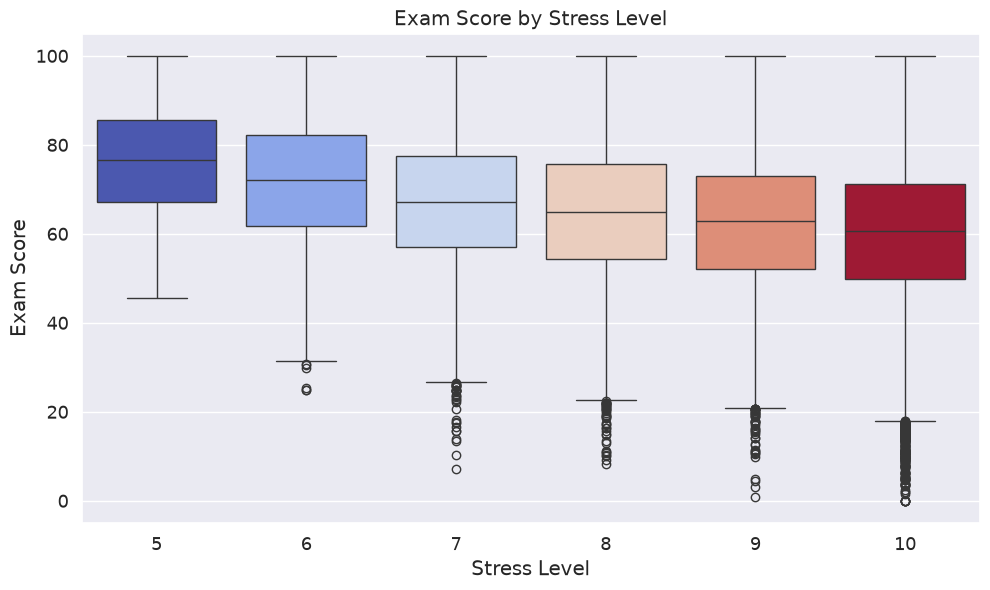

In [108]:
if 'stress_level' in data.columns and 'exam_score' in data.columns:
 
    sns.boxplot(data=data, x='stress_level', y='exam_score', hue='stress_level', palette='coolwarm', legend=False)
    plt.title('Exam Score by Stress Level')
    plt.xlabel('Stress Level')
    plt.ylabel('Exam Score')
    plt.tight_layout()
    plt.show()


MODEL EFFICIENCY PROCEDURE ; DATA LEAKAGE CONTROL MEASURES.

To make the model efficient certain columns that may influence the conclusions without checking the other factors have to be removed.

Determining the coefficient of correlation between question_attempted and questions correct with the final examination score.

In [9]:
data[ 'vercity_ratio' ] = data[ 'questions_correct' ] / data[ 'questions_attempted' ]
print("Average veracity ratio by Pass Status:\n", data.groupby('pass_status')['vercity_ratio'].mean())  
print("Correlation of veracity ratio with the final exam score:\n", round(data['vercity_ratio'].corr(data['exam_score']), 3))
print("Correlation of questions correct with the final exam score:\n", round(data['questions_correct' \
''].corr(data['exam_score']), 3))
data.head(3)

Average veracity ratio by Pass Status:
 pass_status
Fail    0.407747
Pass    0.681319
Name: vercity_ratio, dtype: float64
Correlation of veracity ratio with the final exam score:
 0.995
Correlation of questions correct with the final exam score:
 0.975


,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,attendance_percentage,assignment_completion_rate,class_participation,study_hours_per_day,self_study_hours,private_tuition,online_learning_hours,study_consistency,study_environment,study_method,revision_frequency,practice_tests_completed,notes_quality,sleep_hours,sleep_quality,daily_screen_time,physical_activity_hours,break_frequency,stress_level,motivation_level,internet_access,device_availability,educational_app_usage,online_course_hours,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score,performance_grade,pass_status,performance_level,vercity_ratio
0,STU_000001,20,Female,High School,Public,Middle,NaN,Rural,78.36,2.95,81.49,65.18,Medium,4.94,2.63,0,1.75,Medium,Moderate,Flashcards,Rarely,8,Average,6.31,Excellent,3.80,0.93,Frequently,10,High,1,Shared,Low,2.15,Medium,27,95,86,NaN,9.39,90.40,A,Pass,High,0.905263
1,STU_000002,17,Male,High School,Public,Middle,NaN,Suburban,73.40,2.89,NaN,76.53,Low,3.42,2.64,0,1.97,Medium,Moderate,Flashcards,Daily,10,Average,6.81,Excellent,4.04,0.21,Frequently,8,High,1,Shared,Moderate,4.37,Easy,4,100,86,87.17,6.31,86.21,A,Pass,High,0.860000
2,STU_000003,18,Other,Undergraduate,Public,Middle,Master,Urban,82.76,3.35,100.00,70.39,Medium,1.06,0.83,0,3.40,Low,Moderate,Summarizing,Weekly,5,Excellent,6.53,Poor,3.19,2.56,Rarely,9,Medium,1,Dedicated,Low,1.43,Easy,28,96,74,63.77,9.87,76.11,B,Pass,Medium,0.770833


A HEATMAP OF THE CORRELATION BETWEEN THE STUDENT HABITS, PAST EXPERIENCES AND THE TARGET VARIABLE (BEFORE FILLING THE NULL)

<Axes: >

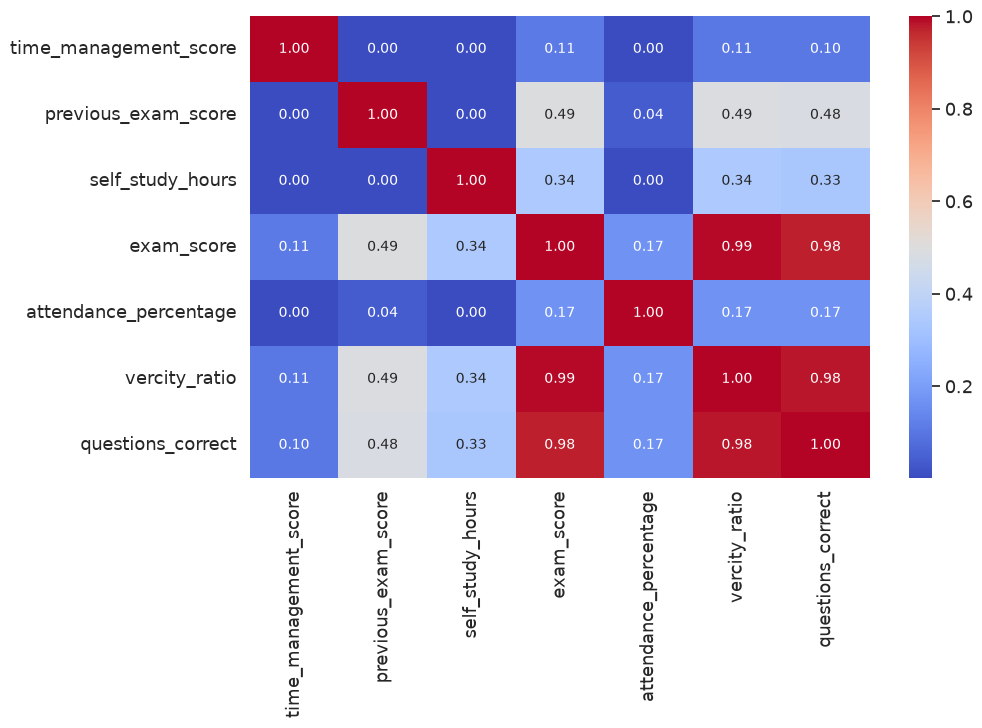

In [85]:
sns.heatmap(data[['time_management_score','previous_exam_score','self_study_hours','exam_score','attendance_percentage','vercity_ratio','questions_correct']].corr(), annot=True, cmap='coolwarm', fmt='.2f')

Key Findings

1. Question_correct And Question_attempted and any ratio built from them are data leakages since they can be used to determine the exam_score because of its high correlation (0.995)
2. These field can directly influence the model to return a pass for a student without looking at other metrics and therefore to have an efficient model we are required to ommit these fields so that the the model can make its predictions off study_habits and other fields.

In [10]:
drop_columns=[ 'performance_grade', 'exam_score', 'questions_attempted', 'questions_correct',
                          'performance_level', 'vercity_ratio',]
data_model = data.drop(columns=drop_columns)
end_goal = 'pass_status'
data_model[end_goal].value_counts()
matrix_x = data_model.drop(columns=[end_goal])

print("Shape of the feature matrix:", matrix_x.shape[1])


Shape of the feature matrix: 38


MODEL ESSAY

Ideally we would remove the null entry rows. But due to large number of missing data we would have to fill them out by th medians of the given columns for numerical data and then fill out with the modal entry in categorical column.

In [117]:
numerical_col=matrix_x.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_col=matrix_x.select_dtypes(include=['object','str']).columns.tolist()

print("Numerical columns:"+"\n", numerical_col)
print("Categorical columns:"+"\n", categorical_col)

Numerical columns:
 ['age', 'previous_exam_score', 'previous_gpa', 'attendance_percentage', 'assignment_completion_rate', 'study_hours_per_day', 'self_study_hours', 'private_tuition', 'online_learning_hours', 'practice_tests_completed', 'sleep_hours', 'daily_screen_time', 'physical_activity_hours', 'stress_level', 'internet_access', 'online_course_hours', 'exam_preparation_days', 'time_management_score', 'exam_anxiety_level']
Categorical columns:
 ['student_id', 'gender', 'education_level', 'school_type', 'family_income', 'parent_education', 'urban_rural', 'class_participation', 'study_consistency', 'study_environment', 'study_method', 'revision_frequency', 'notes_quality', 'sleep_quality', 'break_frequency', 'motivation_level', 'device_availability', 'educational_app_usage', 'exam_difficulty']


In [12]:
matrix_y = data_model['pass_status'].map({'Pass': 1, 'Fail': 0})
print("End goal variable distribution:\n", matrix_y.value_counts(normalize=True).round(3))


End goal variable distribution:
 pass_status
1    0.774
0    0.226
Name: proportion, dtype: float64


TRAIN & EVALUATION

In [116]:
matrix_x_train, matrix_x_test, matrix_y_train, matrix_y_test = train_test_split(
    matrix_x, matrix_y, test_size=0.2, random_state=RANDOM_STATE, stratify=matrix_y
)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_col),
    ('cat', categorical_transformer, categorical_col)
])

print("Train shape:", matrix_x_train.shape, " Test shape:", matrix_x_test.shape)

Train shape: (80000, 38)  Test shape: (20000, 38)


In [118]:
results = {}

def train (name, model):
    pl = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pl.fit(matrix_x_train, matrix_y_train)

    y_prediction = pl.predict(matrix_x_test)
    y_probability = pl.predict_proba(matrix_x_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(matrix_y_test, y_prediction),
        'Precision': precision_score(matrix_y_test, y_prediction),
        'Recall': recall_score(matrix_y_test, y_prediction),
        'F1': f1_score(matrix_y_test, y_prediction),
        'ROC-AUC': roc_auc_score(matrix_y_test, y_probability)
    }
    results[name] = metrics

    print(f"--- {name} ---")
    for g, f in metrics.items():
        print(f"{g}: {f:.4f}")

    return pl, y_prediction, y_probability

1) LOGISTICS REGRESSION => FIRST MODEL

In [79]:
logR = LogisticRegression(random_state=RANDOM_STATE)
logR_pipeline, logR_y_prediction, logR_y_probability = train("Logistic Regression", logR)

--- Logistic Regression ---
Accuracy: 0.8473
Precision: 0.8757
Recall: 0.9355
F1: 0.9046
ROC-AUC: 0.8922


2) XGBOOST CLASSIFIER

In [119]:
XGB = XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss')
xgb_pipeline, xgb_y_prediction, xgb_y_probability = train("XGBoost Classifier", XGB)

/var/data/python/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [03:56:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Classifier ---
Accuracy: 0.8500
Precision: 0.8829
Recall: 0.9295
F1: 0.9056
ROC-AUC: 0.8937


MODEL COMPARISON.

In [124]:
results_df = pd.DataFrame(results).T.sort_values(by='ROC-AUC', ascending=False)
results_df.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
XGBoost Classifier,0.85,0.8829,0.9295,0.9056,0.8937


XGBoost turns Out as the best model due to the high accuracy

ROC- COMPARISON

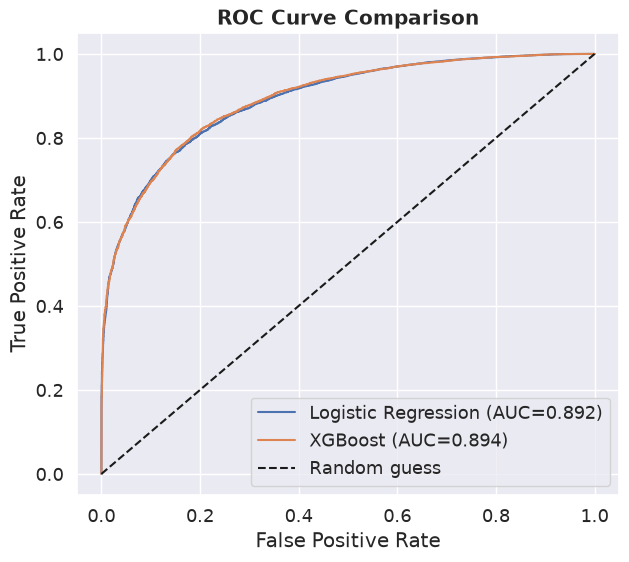

In [131]:
plt.figure(figsize=(7, 6))
for name, prob in [('Logistic Regression', logR_y_probability), ('XGBoost', xgb_y_probability)]:
    fpr, tpr, _ = roc_curve(matrix_y_test, prob)
    auc = roc_auc_score(matrix_y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison",fontweight='bold')
plt.legend()
plt.show()

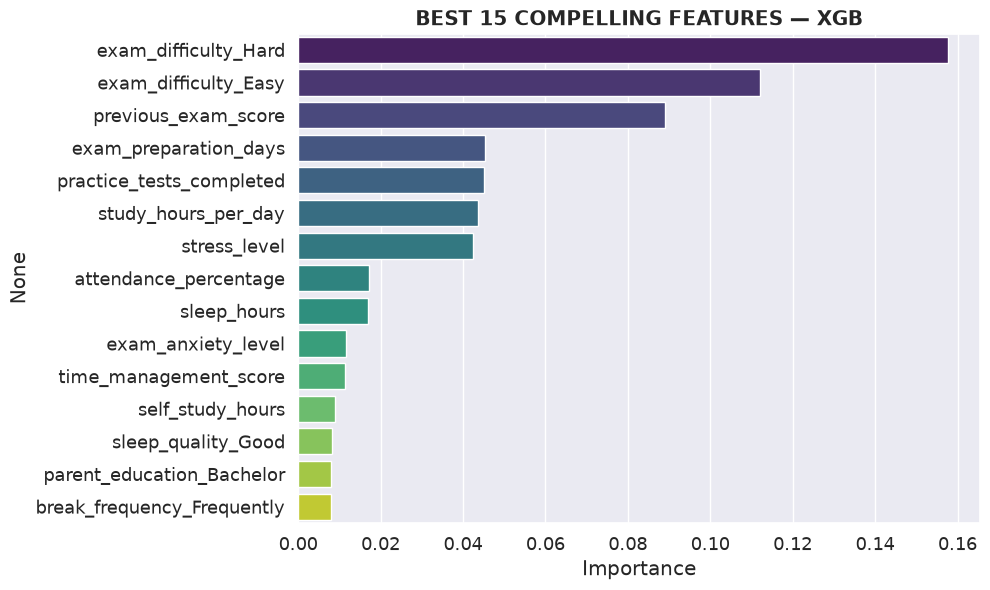

In [148]:
best_model_name = results_df['ROC-AUC'].idxmax()
# normalize name for the downstream dict keys then pick the pipeline
if best_model_name == 'XGBoost Classifier':
    best_model_name = 'XGB'
best_pipe = {'Logistic Regression': logR_pipeline, 'XGB': xgb_pipeline}[best_model_name]
best_prob = {'Logistic Regression': logR_y_probability,  'XGB': xgb_y_probability}[best_model_name]
best_pred = {'Logistic Regression': logR_y_prediction,  'XGB': xgb_y_prediction}[best_model_name]


feature_names = (numerical_col +
    list(best_pipe.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(categorical_col)))

if best_model_name == 'Logistic Regression':
    importances = np.abs(best_pipe.named_steps['classifier'].coef_[0])
else:
    importances = best_pipe.named_steps['classifier'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index,hue=feat_imp.index, palette='viridis')
plt.title(f"BEST 15 COMPELLING FEATURES — {best_model_name}",fontweight='bold')
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

CONCLUSION AND FEATURE WORK

The analysis reveals several intresting points;

1) THE EDA

It shows us how numerous lifestyle and academic factors play a part in influencing students examination results.
We also came to find out the pass mark of the final examination to be 50 which was ahieved by 77,389 students.

2) DATA LEAKAGE 
Basing from the findings in the EDA we got to see that some data columns would result in 'cheating' by the model due to high correlation from the columns itself and any ratio derived from them.

For future work I would advise to use more complex models to get more insights out of the data by mapping more categorical columns.

